In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from micrograd.engine import Value
from micrograd.nn import Neuron, Layer, MLP

In [3]:
## For generating same random array use np.random.seed()
np.random.seed(1337)
random.seed(1337)

In [4]:
# Make a dataset

from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=200, centers=2,
    n_features=2,
    random_state=1150) 

y = y * 2 - 1 # Make y either -1 or 1 for classification


In [5]:
X = (X - X.mean(axis=0)) / X.std(axis=0)

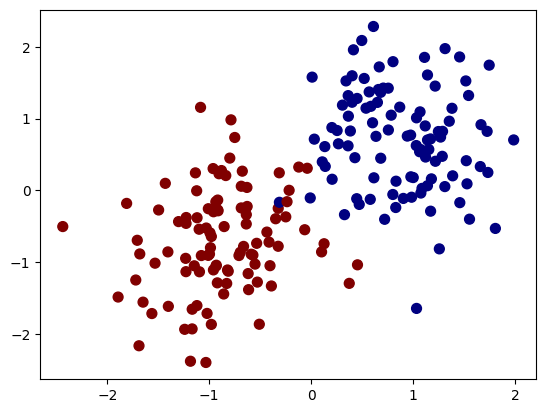

In [6]:
plt.scatter(X[:,0], X[:,1], c = y, s = 50, cmap='jet')

In [7]:
# Initialize the Neural Network
model = MLP(2, [16, 16, 1])
print(model)
print("number of parameters", len(model.parameters()))

MLP of [Layer of [ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2)], Layer of [ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16)], Layer of [LinearNeuron(16)]]
number of parameters 337


In [8]:
# Loss function
def loss():
    Xb, yb = X, y

    inputs = [list(map(Value, xrow)) for xrow in Xb]

    # Forward Pass
    scores = list(map(model, inputs))

    # SVM max margin loss
    losses = [(1 + -yi*scorei).relu() for yi, scorei in zip(yb, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))
    # L2 - regularization
    alpha = 1e-4
    reg_loss = alpha * sum((p*p for p in model.parameters()))
    total_loss = data_loss + reg_loss
    # also get accuracy
    accuracy = [(yi > 0) == (scorei.data > 0) for yi, scorei in zip(yb, scores)]
    return total_loss, sum(accuracy) / len(accuracy)

total_loss, acc = loss()
print(total_loss, acc)

Value(data = 1.4504815052904205, grad = 0.0) 0.495


In [9]:
# Optimization
for k in range(100):

    # Forward Pass
    total_loss, acc = loss()

    # Backpropogation
    model.zero_grad()
    total_loss.backward()

    # update (sgd)
    learning_rate = 0.05 * (1.0 - 0.9 * k / 100)
    for p in model.parameters():
        p.data -= learning_rate * p.grad
    
    if k % 1 == 0:
        print(f"step {k} loss {total_loss.data}, accuracy {acc*100}%")

step 0 loss 1.4504815052904205, accuracy 49.5%
step 1 loss 1.1061824197057275, accuracy 49.5%
step 2 loss 0.7915762159028917, accuracy 64.5%
step 3 loss 0.542144477764961, accuracy 74.5%
step 4 loss 0.4269083101529702, accuracy 80.5%
step 5 loss 0.36632247700526693, accuracy 82.5%
step 6 loss 0.3249681356141871, accuracy 84.5%
step 7 loss 0.2972700055883765, accuracy 88.5%
step 8 loss 0.2772825461952724, accuracy 88.5%
step 9 loss 0.2588646501753799, accuracy 90.0%
step 10 loss 0.24253850796142565, accuracy 91.5%
step 11 loss 0.22779747666674285, accuracy 92.0%
step 12 loss 0.21447965053047943, accuracy 92.0%
step 13 loss 0.20341748898494194, accuracy 92.5%
step 14 loss 0.19344087080352063, accuracy 92.5%
step 15 loss 0.18495300313377594, accuracy 93.0%
step 16 loss 0.17714396111001776, accuracy 93.5%
step 17 loss 0.17028843543364175, accuracy 94.0%
step 18 loss 0.16400524748342798, accuracy 94.0%
step 19 loss 0.15829908628211847, accuracy 94.0%
step 20 loss 0.15396662617331838, accura

(-3.400790099064534, 3.099209900935466)

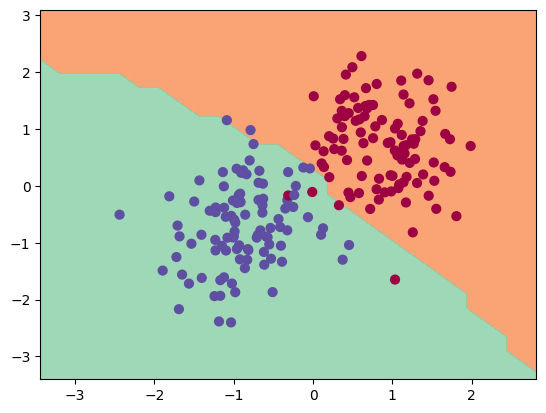

In [10]:
# visualize decision boundary

h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())